STOCK MARKET DATASET:


Dataset: https://www.kaggle.com/datasets/ziya07/stock-market-dataset/data



SECTION A - DATASET & EDA

A1: Dataset Loading & Audit

In [48]:
#importing libraries

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#imports for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#imports for classification track
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

#imports for reports
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    classification_report
)

In [49]:
#loading datasets

df = pd.read_csv("stock_data.csv")

In [50]:
#displays the first rows
print(df.head())
print()
#displays the dataset shape
print("No: of rows:", df.shape[0])  
print("No: of columns:", df.shape[1])
print()
#displays column datatypes
print(df.dtypes)  
 

       Open     Close      High       Low    Volume       RSI      MACD  \
0  0.374639  0.374780  0.373510  0.378390  0.298909  0.847286  0.741715   
1  0.950982  0.937746  0.938422  0.946158  0.094805  0.494543  0.881343   
2  0.732198  0.719825  0.723644  0.723158  0.126348  0.195471  0.463179   
3  0.598823  0.599865  0.596973  0.605322  0.180662  0.736684  0.289076   
4  0.156053  0.163410  0.155891  0.166084  0.203646  0.418698  0.318761   

   Bollinger_Upper  Bollinger_Lower  Sentiment_Score  GDP_Growth  \
0         0.367146         0.366420         0.877177    0.580868   
1         0.938396         0.935640         0.907192    0.527044   
2         0.710666         0.702300         0.378363    0.351052   
3         0.593793         0.586936         0.231614    0.493274   
4         0.164158         0.156355         0.191642    0.365116   

   Inflation_Rate  Target  
0        0.038604       0  
1        0.108908       0  
2        0.432540       0  
3        0.946349       0  


In [51]:
# display missing Values
print(df.isnull().sum())
print()
# displays the number of duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Open               0
Close              0
High               0
Low                0
Volume             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
Sentiment_Score    0
GDP_Growth         0
Inflation_Rate     0
Target             0
dtype: int64

Number of duplicate rows: 0


In [52]:
# Target Distribution - classification target - TARGET
print(df["Target"].value_counts())

Target
0    9405
1     595
Name: count, dtype: int64


A2: EDA Visualisations


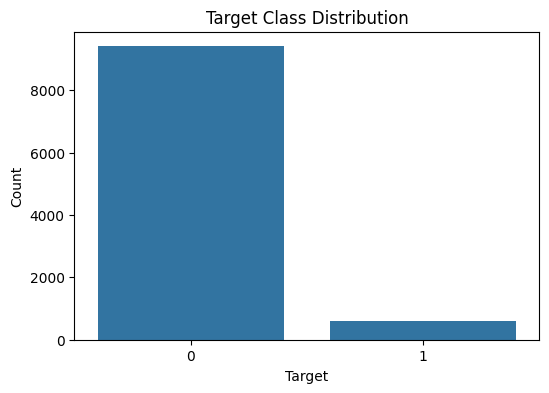

In [53]:
#Countplot for Target class distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Target")

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

Observation:

The target distribution shows the number of observations belonging to each class. This can be used to determine whether the classification dataset is balanced or whether one class is more frequent than the other.

This is important as severe class imbalance can affect the classification model performance 

class 0: More observations

class 1: Less observations

This indicates imbalance. Therefore accuracy alone may not fully represent classification performance. Precision, recall, F1-score and ROC_AUC should also be considered.

In [54]:
# Identifying numerical columns
numeric_columns = df.drop(columns=["Target"]).select_dtypes(
    include=np.number
).columns

for i in numeric_columns:
    print(i)

Open
Close
High
Low
Volume
RSI
MACD
Bollinger_Upper
Bollinger_Lower
Sentiment_Score
GDP_Growth
Inflation_Rate


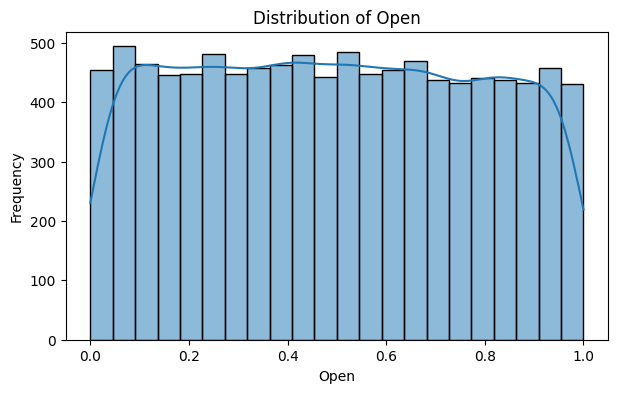

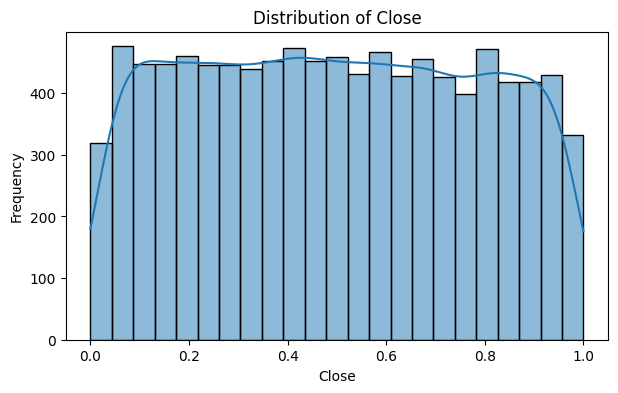

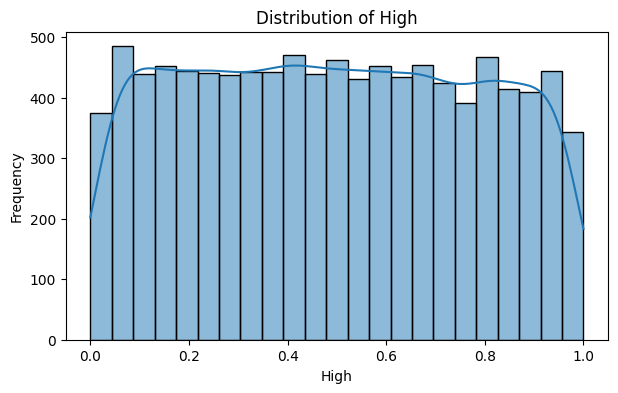

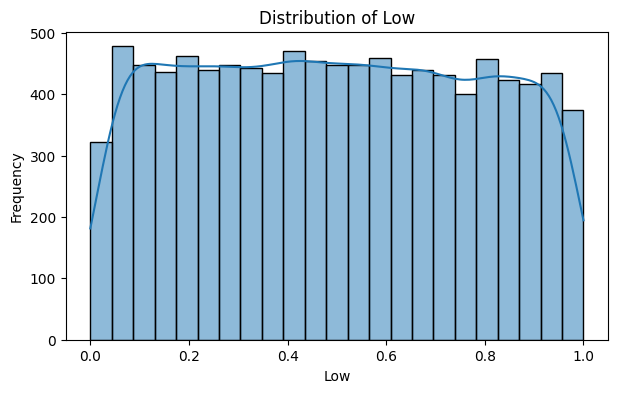

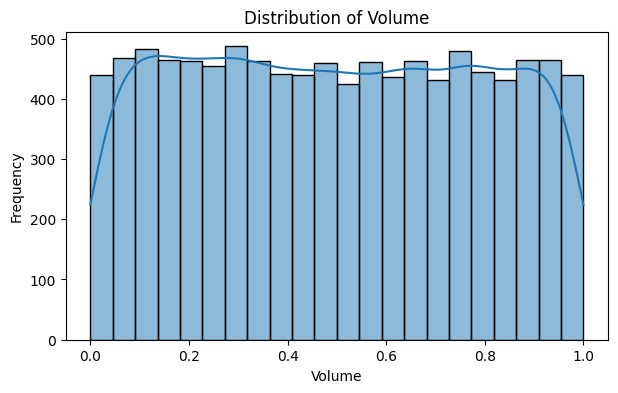

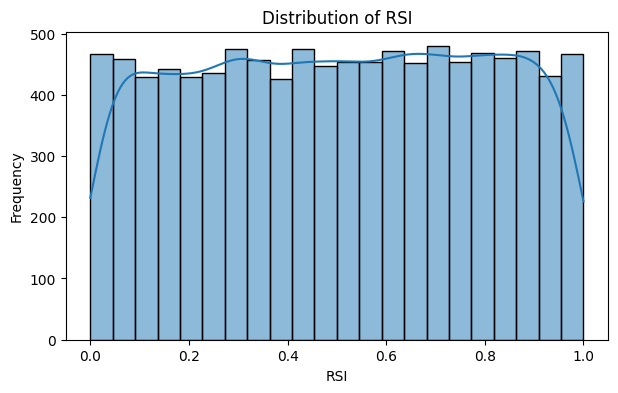

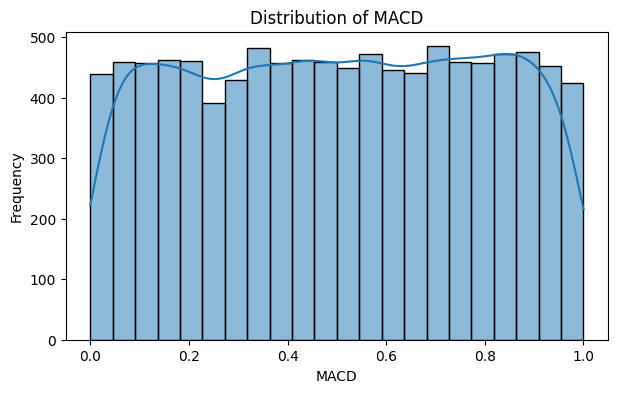

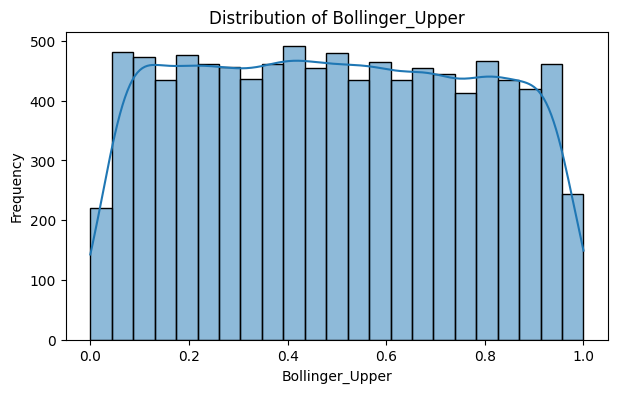

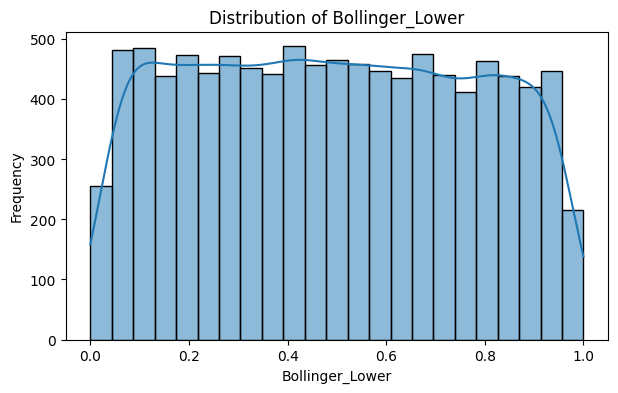

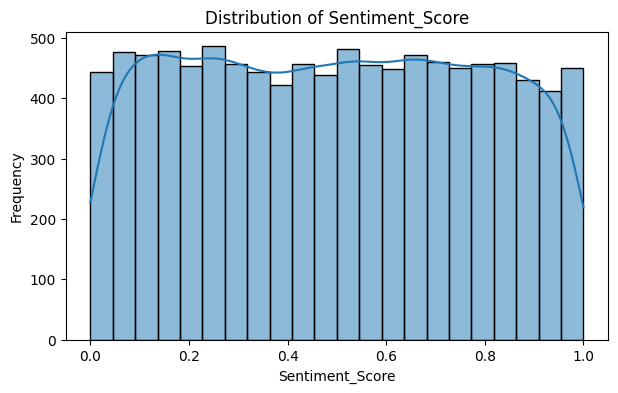

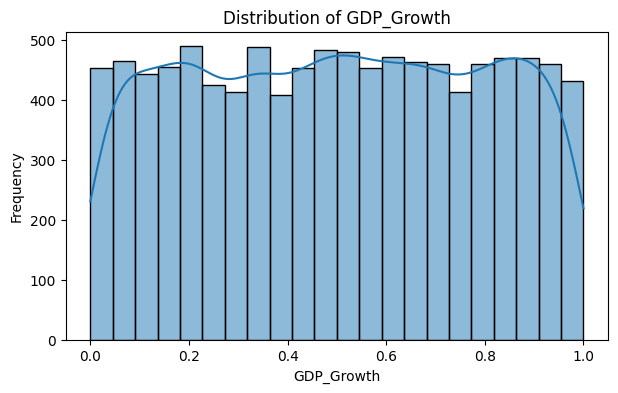

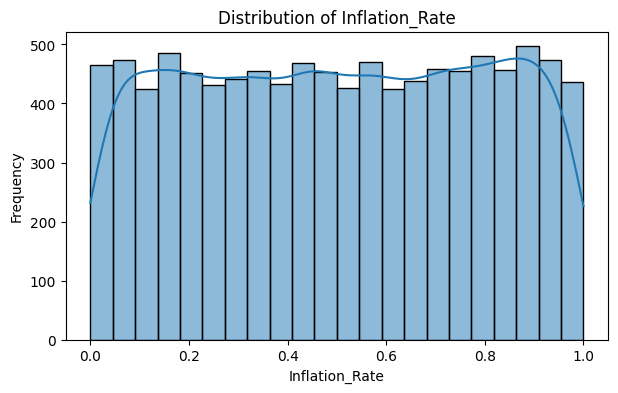

In [55]:
# Histplot for every numerical feature

for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

Observation: 

The distribution plots show the spread and shape of the numerical features. Some variables may show approximately symmetric distributions, while others may be skewed. Features with strong skewness or extreme values may require scaling or appropriate preprocessing before applying machine-learning algorithms.

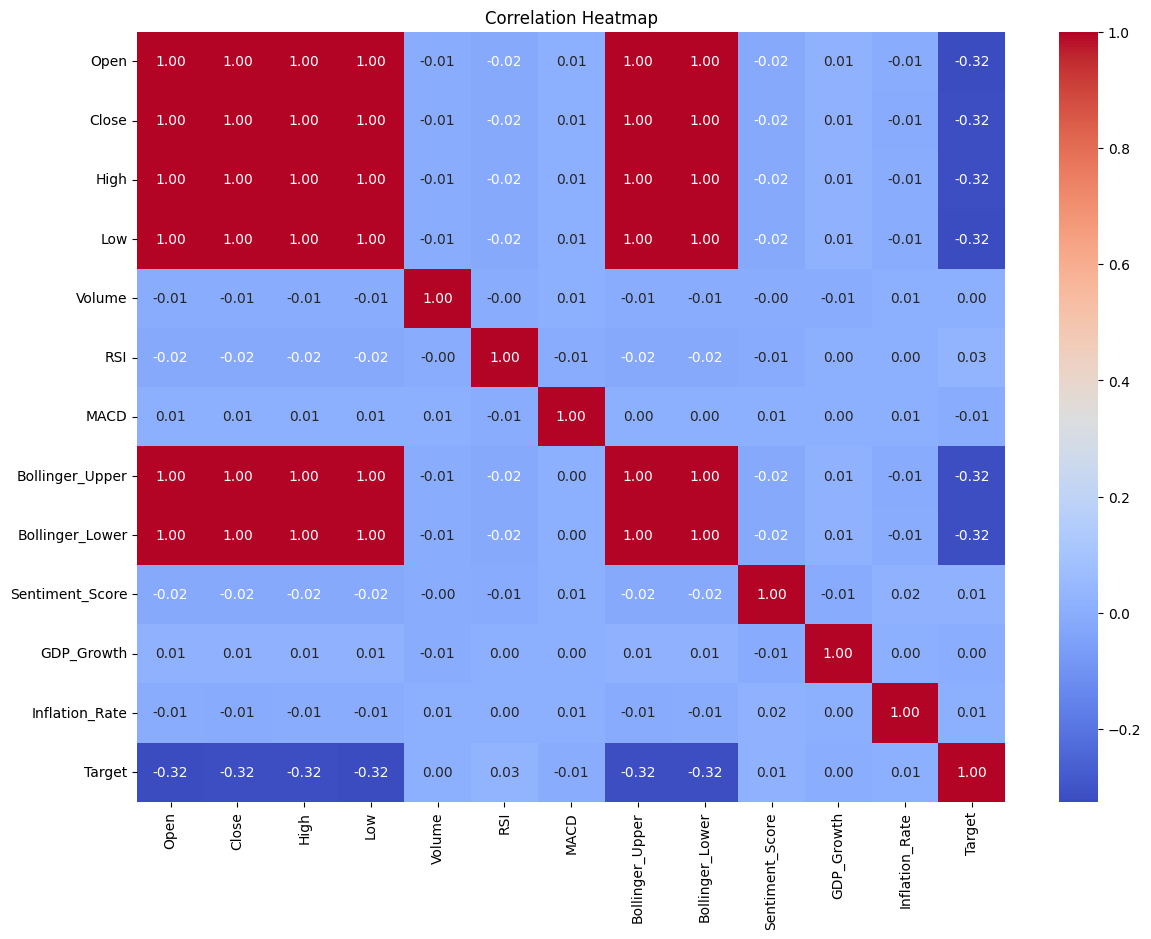

In [56]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Observation: 

The correlation heatmap shows the strength and direction of relationships between numerical variables. Highly positive correlations indicate that two variables tend to increase together, while negative correlations indicate an inverse relationship. Strong correlations between predictors should be considered when interpreting model coefficients and feature importance.

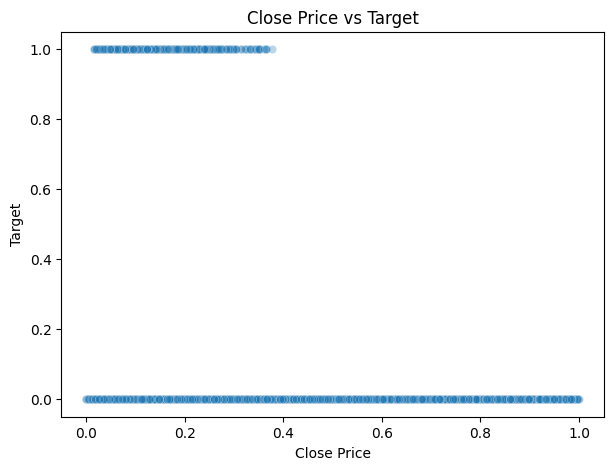

In [57]:
# Scatter plot showing the relationship between the closing price and target class

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Close",
    y="Target",
    alpha=0.3
)

plt.title("Close Price vs Target")
plt.xlabel("Close Price")
plt.ylabel("Target")

plt.show()

Observation:

The scatter plot shows the relationship between the closing price and the target class. Since the target is categorical/binary, the observations appear in distinct horizontal levels corresponding to the target classes. The degree of overlap between the classes provides an initial indications of how well the closing price alone may distinguish the target classes.

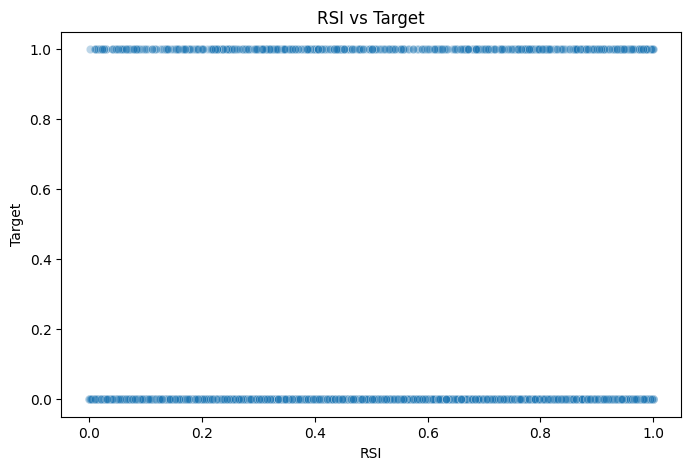

In [58]:
# RSI vs Target

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="RSI",
    y="Target",
    alpha=0.3
)
plt.title("RSI vs Target")
plt.xlabel("RSI")
plt.ylabel("Target")
plt.show()

Observations: 

The scatter plot shows the relationship between RSI and the target variable. There is substantial overlap in RSI values between the two classes (0 & 1). This indicates that RSI alone does not provide clear separation between the target classes, suggesting that a combination of multiple features may be required for better classfication.

SECTION B - PREPROCESSING & FEATURE ENGINEERING

B1: Data Cleaning

In [59]:
X = df.drop(columns=["Target"])
y = df["Target"]

print("Features:", X.columns.tolist())
print()
print("Target:", y.name)

Features: ['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD', 'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth', 'Inflation_Rate']

Target: Target


In [60]:
# display missing Values
print(df.isnull().sum())


Open               0
Close              0
High               0
Low                0
Volume             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
Sentiment_Score    0
GDP_Growth         0
Inflation_Rate     0
Target             0
dtype: int64


Since there are no missing values in the dataset, no imputation is required

In [61]:
# makes sure only numerical columns remain

X = X.select_dtypes(include=np.number)

In [62]:
# handling duplicates

duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


Since there are no duplicates, we are not dropping any columns

In [63]:
# handling outliers

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (X < (Q1 - 1.5 * IQR)) |
    (X > (Q3 + 1.5 * IQR))
)

print("Outliers per feature:")
print(outlier_mask.sum())

Outliers per feature:
Open               0
Close              0
High               0
Low                0
Volume             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
Sentiment_Score    0
GDP_Growth         0
Inflation_Rate     0
dtype: int64


Outliers were checked for all numerical features using the Interquartile Range (IQR) method. No outliers were detected in the dataset. Therefore, no outlier removal or transformation was required, and all observations were retained for further analysis and model training.

In [64]:
# checking if
#    (i) the columns have been removed or not
#    (ii) missing values are handled
#    (iii) only numerical columns remain

print(X.shape)
print(X.columns)

(10000, 12)
Index(['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD',
       'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth',
       'Inflation_Rate'],
      dtype='str')


B3: Feature Engineering

In [65]:
# Feature Engineering - Price Range

print(df.columns.tolist()) # checking whether the dataset contains High and Low
print()
df["Price_Change_Percent"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100
print(df.head())

['Open', 'Close', 'High', 'Low', 'Volume', 'RSI', 'MACD', 'Bollinger_Upper', 'Bollinger_Lower', 'Sentiment_Score', 'GDP_Growth', 'Inflation_Rate', 'Target']

       Open     Close      High       Low    Volume       RSI      MACD  \
0  0.374639  0.374780  0.373510  0.378390  0.298909  0.847286  0.741715   
1  0.950982  0.937746  0.938422  0.946158  0.094805  0.494543  0.881343   
2  0.732198  0.719825  0.723644  0.723158  0.126348  0.195471  0.463179   
3  0.598823  0.599865  0.596973  0.605322  0.180662  0.736684  0.289076   
4  0.156053  0.163410  0.155891  0.166084  0.203646  0.418698  0.318761   

   Bollinger_Upper  Bollinger_Lower  Sentiment_Score  GDP_Growth  \
0         0.367146         0.366420         0.877177    0.580868   
1         0.938396         0.935640         0.907192    0.527044   
2         0.710666         0.702300         0.378363    0.351052   
3         0.593793         0.586936         0.231614    0.493274   
4         0.164158         0.156355         0.19164

Price_Change_Percent represents the percentage movement between the opening and closing prices. This provides the normalized measure of daily price movement and can help the classification models distinguish between different market conditions.

B2: Encoding, Scaling & Splitting

In [66]:
# train-test split - separate features and target
# since target is binary, we can use a stratified split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 12)
Testing set: (2000, 12)


In [67]:
# Scaling - Standard Scaler & Encoding - OneHot Encoder


numeric_columns = X_train.select_dtypes(include=np.number).columns
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [68]:
#SMOTE for presprocessing imbalanced dataset

from imblearn.over_sampling import SMOTE
from collections import Counter

# Check class distribution BEFORE SMOTE
print("Before SMOTE:", Counter(y_train))

# Apply SMOTE only to the training set, only after scaling
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution AFTER SMOTE
print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({0: 7524, 1: 476})
After SMOTE: Counter({0: 7524, 1: 7524})


SECTION D - CLASSIFICATION TRACK, PART A

D1: Implementation

D2: Evaluation

In [69]:
#function for evaluation - avoids writing the same evaluation code 10 times

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    
    "Gaussian Naive Bayes": GaussianNB(),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "SVM": SVC(
        C=1,
        kernel="rbf"
    )
}

In [70]:
# train and evaluate all 5 models without SMOTE

results = []
for name, model in models.items():
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Prediction
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    # ROC-AUC needs a probability/score, not a hard 0/1 label
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)   # SVC falls here
    
    roc_auc = roc_auc_score(y_test, y_score)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "ROC-AUC": roc_auc
    })
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    
    print("\nConfusion Matrix:")
    print(cm)
    print()

Logistic Regression
Accuracy: 0.942
Weighted F1: 0.9153
ROC-AUC: 0.9437

Confusion Matrix:
[[1881    0]
 [ 116    3]]

K-Nearest Neighbors
Accuracy: 0.9285
Weighted F1: 0.9127
ROC-AUC: 0.7573

Confusion Matrix:
[[1847   34]
 [ 109   10]]

Gaussian Naive Bayes
Accuracy: 0.787
Weighted F1: 0.8414
ROC-AUC: 0.899

Confusion Matrix:
[[1462  419]
 [   7  112]]

Decision Tree
Accuracy: 0.945
Weighted F1: 0.9258
ROC-AUC: 0.8955

Confusion Matrix:
[[1876    5]
 [ 105   14]]

SVM
Accuracy: 0.9405
Weighted F1: 0.9117
ROC-AUC: 0.9694

Confusion Matrix:
[[1881    0]
 [ 119    0]]



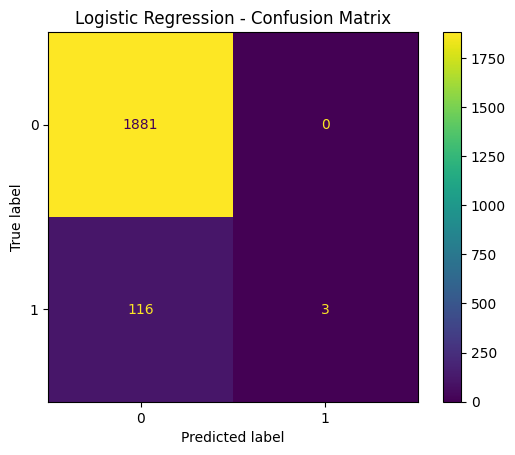

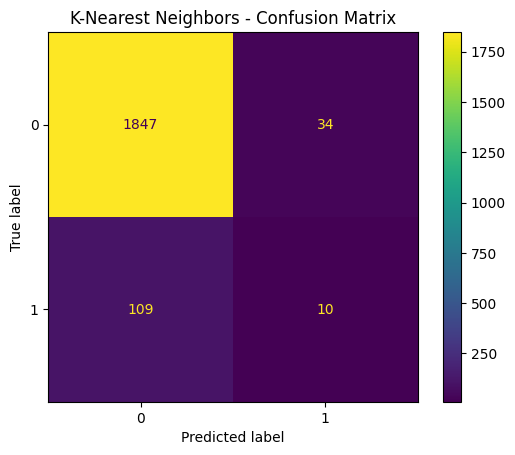

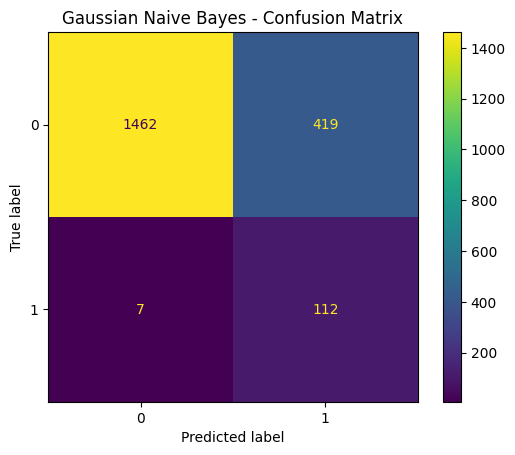

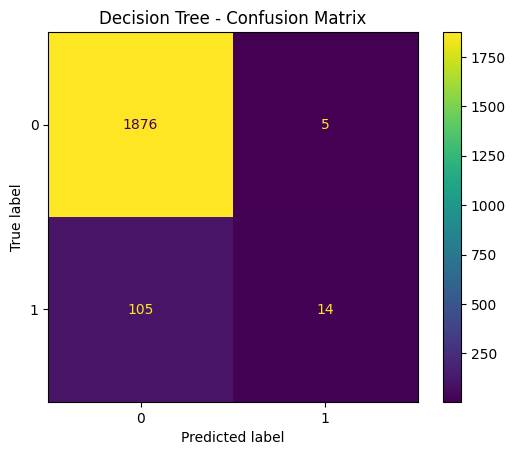

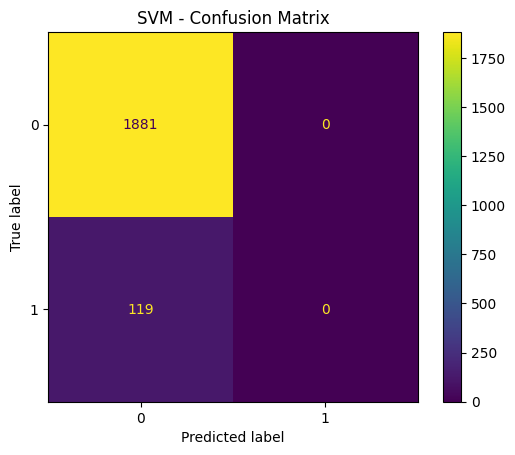

In [71]:
# displays the confusion matrices for each model

for name, model in models.items():
    
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )
    
    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()

In [72]:
# Preliminary Comparison Table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Algorithm,Accuracy,Weighted F1,ROC-AUC
0,Decision Tree,0.9450,0.925785,0.895496
1,Logistic Regression,0.9420,0.915294,0.943651
2,SVM,0.9405,0.911662,0.969357
3,K-Nearest Neighbors,0.9285,0.912749,0.757314
4,Gaussian Naive Bayes,0.7870,0.841407,0.898954


Based on Accuracy and Weighted F1 alone, the Decision Tree ranks best (Accuracy: 0.945, 
Weighted F1: 0.9258), followed by Logistic Regression, SVM, KNN, and Gaussian Naive Bayes 
last (Accuracy: 0.787).

However, since the target is imbalanced (94% class 0, 6% class 1), Accuracy and even 
Weighted F1 can be misleading — a model that mostly predicts the majority class will still 
score highly on both metrics without actually learning to identify the minority class. 
This is confirmed by the confusion matrices: SVM achieves 94.05% accuracy while catching 
0 of 119 real class-1 cases in the test set, and Logistic Regression catches only 3 of 119. 

This indicates that Accuracy and Weighted F1 alone are not sufficient to judge these 
models fairly on this dataset, and a threshold-independent metric such as ROC-AUC is 
needed to properly assess each model's ability to separate the two classes.

In [73]:
results_smote = []

for name, model in models.items():
    
    # Train on RESAMPLED training data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predict on the ORIGINAL, untouched test set
    y_pred = model.predict(X_test_scaled)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_score)
    cm = confusion_matrix(y_test, y_pred)
    
    results_smote.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "ROC-AUC": roc_auc
    })
    
    print("=" * 60)
    print(name, "(with SMOTE)")
    print("=" * 60)
    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("Confusion Matrix:\n", cm)
    print()


Logistic Regression (with SMOTE)
Accuracy: 0.877
Weighted F1: 0.9035
ROC-AUC: 0.9764
Confusion Matrix:
 [[1640  241]
 [   5  114]]

K-Nearest Neighbors (with SMOTE)
Accuracy: 0.82
Weighted F1: 0.8611
ROC-AUC: 0.8025
Confusion Matrix:
 [[1564  317]
 [  43   76]]

Gaussian Naive Bayes (with SMOTE)
Accuracy: 0.779
Weighted F1: 0.8358
ROC-AUC: 0.8972
Confusion Matrix:
 [[1446  435]
 [   7  112]]

Decision Tree (with SMOTE)
Accuracy: 0.7955
Weighted F1: 0.8473
ROC-AUC: 0.9041
Confusion Matrix:
 [[1479  402]
 [   7  112]]

SVM (with SMOTE)
Accuracy: 0.789
Weighted F1: 0.8428
ROC-AUC: 0.9291
Confusion Matrix:
 [[1465  416]
 [   6  113]]



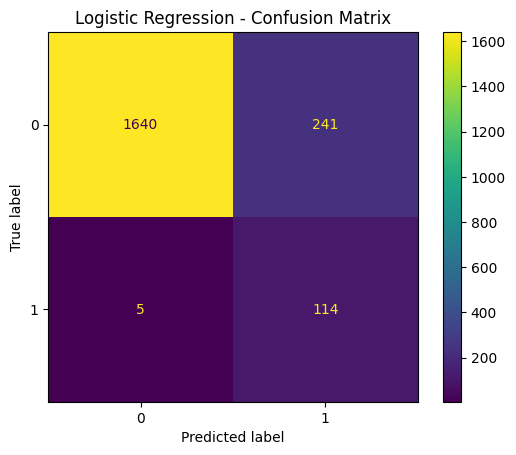

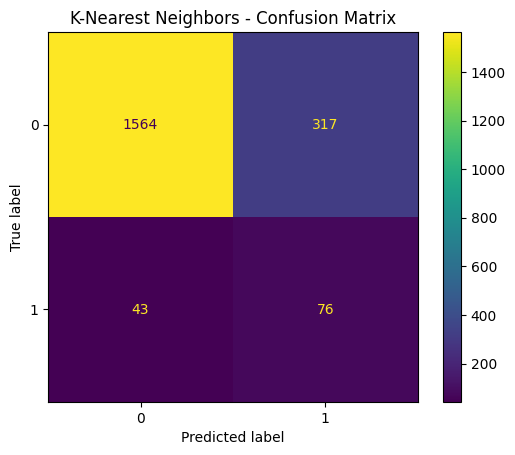

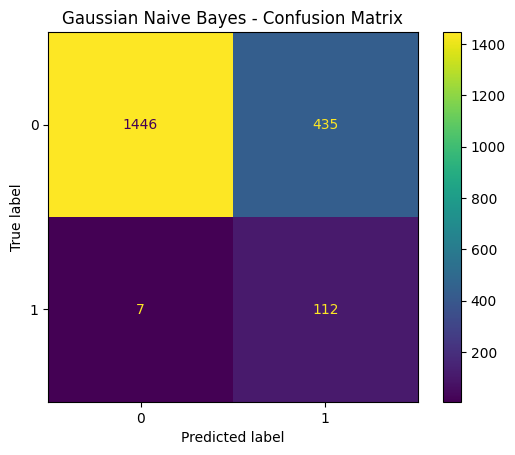

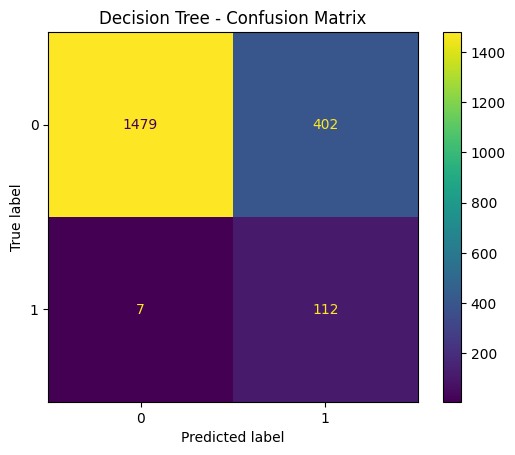

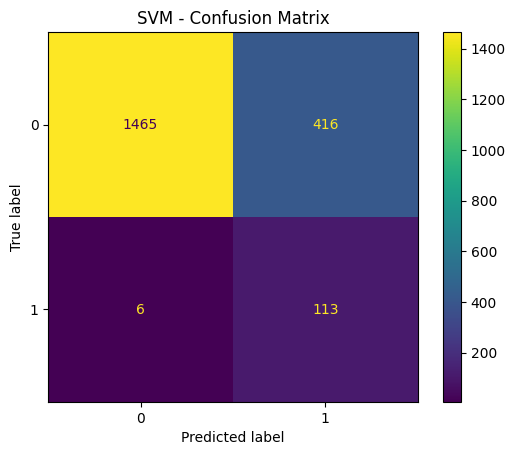

In [74]:
# displays the confusion matrices for each model after using SMOTE for imbalanced dataset

for name, model in models.items():
    
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )
    
    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()

In [75]:
results_smote_df = pd.DataFrame(results_smote).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_smote_df

,Algorithm,Accuracy,Weighted F1,ROC-AUC
0,Logistic Regression,0.8770,0.903504,0.976376
1,SVM,0.7890,0.842847,0.929110
2,Decision Tree,0.7955,0.847310,0.904101
3,Gaussian Naive Bayes,0.7790,0.835827,0.897243
4,K-Nearest Neighbors,0.8200,0.861094,0.802528


Observation:

Applying SMOTE to the training set produces a clear trade-off: overall Accuracy and 
Weighted F1 drop for almost every model, while ROC-AUC improves for most of them.

Accuracy and Weighted F1 fall for every model after SMOTE, most sharply for SVM (0.9405 
→ 0.7890) and Decision Tree (0.9450 → 0.7955). This is expected, not a failure: SMOTE 
rebalances the training data to 50/50, so these models now predict class 1 far more 
often than before. Since the test set is still 94% class 0, every extra class-1 
prediction that turns out wrong now directly reduces overall accuracy — the model is 
trading some majority-class precision for better minority-class detection.

Logistic Regression stands out as the strongest model after SMOTE: it has the 
highest Accuracy (0.8770), highest Weighted F1 (0.9035), and highest ROC-AUC (0.9764) 
of all five models — and its ROC-AUC improved further from an already-strong 0.9437. 
This suggests SMOTE helped it learn a better-calibrated decision boundary rather than 
just shifting predictions randomly.

Overall, SMOTE improves the models' underlying ability to rank and detect the minority 
class (reflected in ROC-AUC gains for most models), at the cost of overall accuracy — 
confirming that Accuracy is not a reliable metric on imbalanced data, both before and 
after resampling. Logistic Regression combined with SMOTE appears to be the strongest 
overall approach found in this notebook, balancing all three metrics better than any 
other model/preprocessing combination tested.